In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load NAV Data

In [3]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


## Select 5 Funds

In [4]:
selected_funds = (
    nav["amfi_code"]
    .unique()[:5]
)

print(selected_funds)

[119551 119552 119598 119599 119120]


## Create NAV Matrix

In [5]:
nav_matrix = nav[
    nav["amfi_code"].isin(selected_funds)
]

nav_matrix = nav_matrix.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_matrix.head()

amfi_code,119120,119551,119552,119598,119599
date,,,,,
2022-01-03,42.1391,54.3856,58.4174,89.8738,96.4565
2022-01-04,42.2508,54.3474,57.3480,88.5495,94.6512
2022-01-05,42.4374,54.6869,57.0552,88.0925,94.5436
2022-01-06,42.5901,55.4550,56.4224,88.5175,93.7944
2022-01-07,42.4851,55.3692,57.2750,91.4235,89.6438


## Calculate Daily Returns

In [6]:
returns = nav_matrix.pct_change()

returns = returns.dropna()

returns.head()

amfi_code,119120,119551,119552,119598,119599
date,,,,,
2022-01-04,0.002651,-0.000702,-0.018306,-0.014735,-0.018716
2022-01-05,0.004416,0.006247,-0.005106,-0.005161,-0.001137
2022-01-06,0.003598,0.014045,-0.011091,0.004824,-0.007924
2022-01-07,-0.002465,-0.001547,0.015111,0.032830,-0.044252
2022-01-10,-0.000353,-0.001548,0.009465,0.051113,0.033761


## Calculate Annual Returns & Covariance

In [7]:
annual_returns = (
    returns.mean()
    * 252
)

cov_matrix = (
    returns.cov()
    * 252
)

print(annual_returns)

amfi_code
119120    0.056012
119551    0.231033
119552    0.197881
119598    0.302656
119599    0.050732
dtype: float64


## Generate 5000 Random Portfolios

In [8]:
num_portfolios = 5000

portfolio_returns = []
portfolio_risks = []
portfolio_weights = []
sharpe_ratios = []

for _ in range(num_portfolios):

    weights = np.random.random(
        len(selected_funds)
    )

    weights = weights / np.sum(weights)

    port_return = np.sum(
        annual_returns * weights
    )

    port_risk = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                cov_matrix,
                weights
            )
        )
    )

    sharpe = (
        port_return - 0.065
    ) / port_risk

    portfolio_returns.append(
        port_return
    )

    portfolio_risks.append(
        port_risk
    )

    sharpe_ratios.append(
        sharpe
    )

    portfolio_weights.append(
        weights
    )

print("Portfolios Generated:", num_portfolios)

Portfolios Generated: 5000


## Create Portfolio DataFrame

In [9]:
portfolio_df = pd.DataFrame({
    "return": portfolio_returns,
    "risk": portfolio_risks,
    "sharpe": sharpe_ratios
})

portfolio_df.head()

,return,risk,sharpe
0,0.163390,0.080591,1.220863
1,0.144565,0.090227,0.881829
2,0.141108,0.075782,1.004302
3,0.240836,0.120759,1.456095
4,0.193965,0.084496,1.526294


## Find Maximum Sharpe Portfolio

In [10]:
max_sharpe_idx = (
    portfolio_df["sharpe"]
    .idxmax()
)

optimal_weights = (
    portfolio_weights[max_sharpe_idx]
)

optimal_portfolio = pd.DataFrame({
    "amfi_code": selected_funds,
    "weight": optimal_weights
})

optimal_portfolio

,amfi_code,weight
0,119551,0.019307
1,119552,0.448185
2,119598,0.354718
3,119599,0.167008
4,119120,0.010781


## Save Optimal Portfolio

In [11]:
optimal_portfolio.to_csv(
    "../data/processed/optimal_portfolio.csv",
    index=False
)

print(
    "optimal_portfolio.csv saved"
)

optimal_portfolio.csv saved


## Plot Efficient Frontier

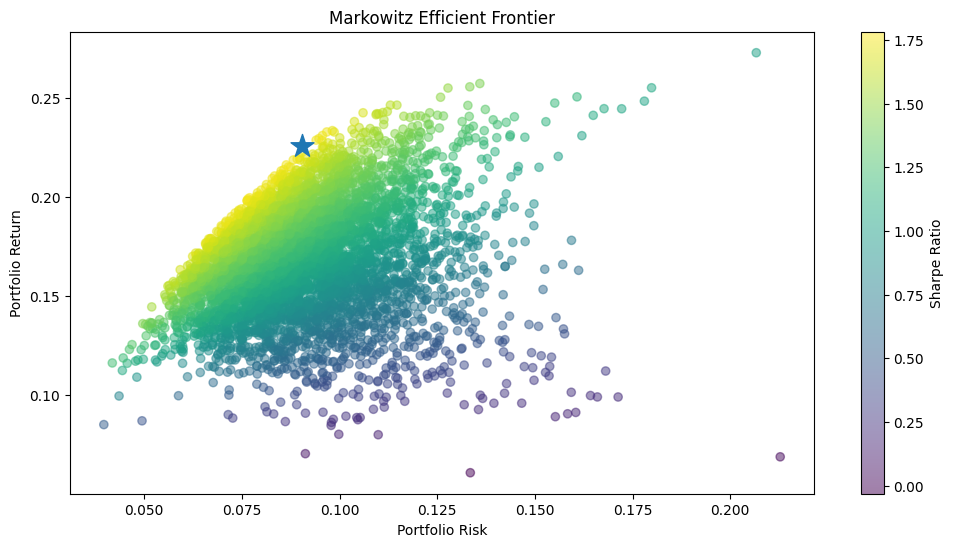

In [12]:
plt.figure(figsize=(12,6))

scatter = plt.scatter(
    portfolio_risks,
    portfolio_returns,
    c=sharpe_ratios,
    alpha=0.5
)

plt.colorbar(
    scatter,
    label="Sharpe Ratio"
)

plt.scatter(
    portfolio_risks[max_sharpe_idx],
    portfolio_returns[max_sharpe_idx],
    marker="*",
    s=300
)

plt.title(
    "Markowitz Efficient Frontier"
)

plt.xlabel(
    "Portfolio Risk"
)

plt.ylabel(
    "Portfolio Return"
)

plt.savefig(
    "../reports/charts/efficient_frontier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()